# FY4B ViT Training Notebook (15-Channel Satellite Version)

This notebook adapts the ViT idea from `vit-cifar-10-ver2.ipynb` to your FY4B cloud-phase classification dataset.

## Main changes
- Input changed from **CIFAR RGB images** to **FY4B 15-channel `.npy` tensors**
- Number of classes changed from **10** to **5**
- Data source changed from **image folders** to **pre-sliced train/test numpy files**
- Added a **scene-level validation split** from the training scenes to avoid using the test set for model selection
- Added **class weights, macro-F1, confusion matrix, and classification report**
- Kept the core ViT structure: patch embedding + transformer encoder + classification head

> The test set is used only for final evaluation.


In [1]:
import os
import json
import math
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ---------------- Config ----------------
class Config:
    # Paths
    data_dir = Path("../data_processed/fy4b_vit_month_stratified_scene_split")
    output_dir = Path("../runs/vit_fy4b_15ch")

    # Data
    img_size = 64
    in_channels = 15
    num_classes = 5
    class_names = ["Clear", "Water", "SuperCooled", "Mixed", "Ice"]
    val_scene_ratio = 0.2
    val_split_trials = 2000
    seed = 42

    # Model
    patch_size = 8
    embed_dim = 256
    depth = 6
    num_heads = 8
    mlp_ratio = 3.0
    dropout = 0.1

    # Training
    batch_size = 128
    num_epochs = 80
    learning_rate = 1e-3
    weight_decay = 5e-2
    label_smoothing = 0.05
    early_stopping_patience = 15

    # Notebook/Windows ???? DataLoader ????????? 0
    num_workers = 0
    pin_memory = torch.cuda.is_available()
    use_amp = torch.cuda.is_available()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()
config.output_dir.mkdir(parents=True, exist_ok=True)
print(f"Using device: {config.device}")
print(f"Data dir: {config.data_dir.resolve()}")
print(f"Output dir: {config.output_dir.resolve()}")

Using device: cuda
Data dir: C:\Users\38851\Desktop\FY数据集\fy4b_vit_month_stratified_scene_split
Output dir: C:\Users\38851\Desktop\FY数据集\runs\vit_fy4b_15ch


In [2]:
# ---------------- Reproducibility ----------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(config.seed)

In [3]:
# ---------------- Load FY4B arrays and metadata ----------------
train_x_path = config.data_dir / "train_x_fy4b.npy"
train_y_path = config.data_dir / "train_y_fy4b.npy"
test_x_path = config.data_dir / "test_x_fy4b.npy"
test_y_path = config.data_dir / "test_y_fy4b.npy"
train_meta_path = config.data_dir / "train_patch_metadata.csv"
test_meta_path = config.data_dir / "test_patch_metadata.csv"
train_scene_manifest_path = config.data_dir / "train_scene_manifest.csv"

required_files = [
    train_x_path, train_y_path, test_x_path, test_y_path,
    train_meta_path, test_meta_path, train_scene_manifest_path,
]
for p in required_files:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

train_x = np.load(train_x_path, mmap_mode="r")
train_y = np.load(train_y_path, mmap_mode="r")
test_x = np.load(test_x_path, mmap_mode="r")
test_y = np.load(test_y_path, mmap_mode="r")

train_meta = pd.read_csv(train_meta_path)
test_meta = pd.read_csv(test_meta_path)
train_scene_manifest = pd.read_csv(train_scene_manifest_path)

print("train_x:", train_x.shape, train_x.dtype)
print("train_y:", train_y.shape, train_y.dtype)
print("test_x :", test_x.shape, test_x.dtype)
print("test_y :", test_y.shape, test_y.dtype)

assert len(train_x) == len(train_y) == len(train_meta)
assert len(test_x) == len(test_y) == len(test_meta)
assert train_x.shape[1] == config.in_channels
assert train_x.shape[2] == train_x.shape[3] == config.img_size
assert len(np.unique(train_y)) == config.num_classes
assert len(np.unique(test_y)) == config.num_classes

train_x: (15263, 15, 64, 64) float16
train_y: (15263,) uint8
test_x : (5957, 15, 64, 64) float16
test_y : (5957,) uint8


In [4]:
# ---------------- Scene-level val split from train split ----------------
# Build a scene-level validation split from the training split so the test set is not used for tuning

def select_val_scenes(train_meta: pd.DataFrame, val_ratio=0.2, seed=42, trials=2000):
    rng = random.Random(seed)

    scene_class_counts = defaultdict(lambda: np.zeros(config.num_classes, dtype=np.int64))
    scene_month = {}
    for _, row in train_meta.iterrows():
        scene = row["start_time"]
        label = int(row["label"])
        month = str(row["month"]).zfill(2)
        scene_class_counts[scene][label] += 1
        scene_month[scene] = month

    scenes = sorted(scene_class_counts.keys())
    by_month = defaultdict(list)
    for scene in scenes:
        by_month[scene_month[scene]].append(scene)

    total_counts = sum((scene_class_counts[s] for s in scenes), np.zeros(config.num_classes, dtype=np.int64))

    # Sample validation scenes month-by-month so validation also covers 01/04/07/10
    month_pick = {}
    for month, scene_list in by_month.items():
        k = max(1, round(len(scene_list) * val_ratio))
        k = min(k, len(scene_list) - 1) if len(scene_list) > 1 else 1
        month_pick[month] = k

    best = None
    scene_pool_by_month = {m: list(v) for m, v in by_month.items()}

    for _ in range(trials):
        candidate = set()
        for month, scene_list in scene_pool_by_month.items():
            candidate.update(rng.sample(scene_list, month_pick[month]))

        val_counts = sum((scene_class_counts[s] for s in candidate), np.zeros(config.num_classes, dtype=np.int64))
        train_counts = total_counts - val_counts

        penalty = 0.0
        # Penalize candidates that remove any class from either sub-train or validation
        if np.any(val_counts == 0):
            penalty += 1e6
        if np.any(train_counts == 0):
            penalty += 1e6

        target = total_counts * val_ratio
        penalty += float(np.mean(((val_counts - target) / np.maximum(target, 1)) ** 2)) * 1000
        penalty += float(np.mean(((train_counts - (total_counts - target)) / np.maximum(total_counts - target, 1)) ** 2)) * 1000

        if best is None or penalty < best[0]:
            best = (penalty, sorted(candidate), val_counts.copy(), train_counts.copy())

    best_val_scenes = set(best[1])
    return best_val_scenes, best[2], best[3]

val_scenes, val_counts, subtrain_counts = select_val_scenes(
    train_meta,
    val_ratio=config.val_scene_ratio,
    seed=config.seed,
    trials=config.val_split_trials,
)

train_scenes = set(train_meta["start_time"].unique())
subtrain_scenes = train_scenes - val_scenes

print(f"Total train scenes   : {len(train_scenes)}")
print(f"Sub-train scenes     : {len(subtrain_scenes)}")
print(f"Validation scenes    : {len(val_scenes)}")
print("Val months           :", sorted({str(s)[4:6] for s in val_scenes}))
print("Sub-train months     :", sorted({str(s)[4:6] for s in subtrain_scenes}))
print("Val scene list       :", sorted(val_scenes))

Total train scenes   : 48
Sub-train scenes     : 40
Validation scenes    : 8
Val months           : ['01', '04', '07', '10']
Sub-train months     : ['01', '04', '07', '10']
Val scene list       : [20250402120000, 20250412060000, 20250722120000, 20250730120000, 20251018060000, 20251018180000, 20260111000000, 20260122060000]


In [5]:
# ---------------- Build sample indices ----------------
subtrain_indices = train_meta.loc[train_meta["start_time"].isin(subtrain_scenes), "sample_index"].to_numpy(dtype=np.int64)
val_indices = train_meta.loc[train_meta["start_time"].isin(val_scenes), "sample_index"].to_numpy(dtype=np.int64)
test_indices = test_meta["sample_index"].to_numpy(dtype=np.int64)

subtrain_labels = train_y[subtrain_indices]
val_labels = train_y[val_indices]
test_labels = test_y[test_indices]

print("Sub-train samples:", len(subtrain_indices))
print("Val samples      :", len(val_indices))
print("Test samples     :", len(test_indices))

print("Sub-train label counts:", dict(Counter(subtrain_labels.tolist())))
print("Val label counts      :", dict(Counter(val_labels.tolist())))
print("Test label counts     :", dict(Counter(test_labels.tolist())))

Sub-train samples: 12409
Val samples      : 2854
Test samples     : 5957
Sub-train label counts: {3: 2207, 0: 2229, 2: 3168, 4: 3249, 1: 1556}
Val label counts      : {4: 703, 0: 458, 2: 750, 1: 382, 3: 561}
Test label counts     : {0: 3590, 4: 1316, 2: 328, 1: 644, 3: 79}


In [6]:
# ---------------- FY4B augmentations and Dataset ----------------
class SatelliteTrainAugment:
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # x: [C, H, W]
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])   # horizontal flip
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[1])   # vertical flip
        k = int(torch.randint(0, 4, (1,)).item())
        x = torch.rot90(x, k, dims=[1, 2])
        return x.contiguous()

class FY4BNpyDataset(Dataset):
    def __init__(self, x_array, y_array, indices, transform=None):
        self.x_array = x_array
        self.y_array = y_array
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = np.array(self.x_array[real_idx], dtype=np.float32, copy=True)
        y = int(self.y_array[real_idx])
        x = torch.from_numpy(x)
        if self.transform is not None:
            x = self.transform(x)
        return x, y

train_dataset = FY4BNpyDataset(train_x, train_y, subtrain_indices, transform=SatelliteTrainAugment())
val_dataset = FY4BNpyDataset(train_x, train_y, val_indices, transform=None)
test_dataset = FY4BNpyDataset(test_x, test_y, test_indices, transform=None)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
)

print(f"train batches: {len(train_loader)} | val batches: {len(val_loader)} | test batches: {len(test_loader)}")

train batches: 97 | val batches: 23 | test batches: 47


In [7]:
# ---------------- Class weights ----------------
train_label_counts = np.bincount(subtrain_labels.astype(np.int64), minlength=config.num_classes)
class_weights = train_label_counts.sum() / np.maximum(train_label_counts, 1)
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=config.device)

print("Train label counts:", train_label_counts.tolist())
print("Class weights     :", class_weights.detach().cpu().numpy().round(4).tolist())

Train label counts: [2229, 1556, 3168, 2207, 3249]
Class weights     : [1.0347000360488892, 1.482300043106079, 0.7279999852180481, 1.0450999736785889, 0.7099000215530396]


In [8]:
# ---------------- ViT model (adapted from CIFAR example) ----------------
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=15, embed_dim=256):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                  # [B, embed_dim, H/P, W/P]
        x = x.flatten(2).transpose(1, 2)  # [B, num_patches, embed_dim]
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=3.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class FY4BViT(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=15, num_classes=5,
                 embed_dim=256, depth=6, num_heads=8, mlp_ratio=3.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_out = x[:, 0]
        logits = self.head(cls_out)
        return logits

model = FY4BViT(
    img_size=config.img_size,
    patch_size=config.patch_size,
    in_channels=config.in_channels,
    num_classes=config.num_classes,
    embed_dim=config.embed_dim,
    depth=config.depth,
    num_heads=config.num_heads,
    mlp_ratio=config.mlp_ratio,
    dropout=config.dropout,
).to(config.device)

num_params = sum(p.numel() for p in model.parameters())
print(model.__class__.__name__)
print(f"Parameters: {num_params:,}")

FY4BViT
Parameters: 4,215,301


In [9]:
# ---------------- Training / evaluation helpers ----------------
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    all_preds = []
    all_targets = []

    for images, labels in loader:
        images = images.to(config.device, non_blocking=True)
        labels = labels.to(config.device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with autocast(enabled=config.use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    metrics = {
        "loss": float(np.mean(losses)),
        "acc": float(accuracy_score(all_targets, all_preds)),
        "macro_f1": float(f1_score(all_targets, all_preds, average="macro")),
        "weighted_f1": float(f1_score(all_targets, all_preds, average="weighted")),
        "preds": all_preds,
        "targets": all_targets,
    }
    return metrics


def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(history["train_macro_f1"], label="train")
    axes[2].plot(history["val_macro_f1"], label="val")
    axes[2].set_title("Macro-F1")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


def plot_confmat(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

C:\Users\38851\AppData\Local\Temp\ipykernel_47852\1381690870.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=config.use_amp)
C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):
C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


Epoch [001/80] | train_loss=0.6554 val_loss=0.4879 | train_acc=0.8199 val_acc=0.8970 | train_f1=0.7920 val_f1=0.8792


C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):
C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


Epoch [002/80] | train_loss=0.4680 val_loss=0.5204 | train_acc=0.9163 val_acc=0.8651 | train_f1=0.8959 val_f1=0.8420


C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):
C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


...

Epoch [078/80] | train_loss=0.2474 val_loss=0.2772 | train_acc=0.9970 val_acc=0.9898 | train_f1=0.9960 val_f1=0.9874


C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):
C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


Epoch [079/80] | train_loss=0.2467 val_loss=0.2773 | train_acc=0.9969 val_acc=0.9898 | train_f1=0.9958 val_f1=0.9874


C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):
C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


Epoch [080/80] | train_loss=0.2471 val_loss=0.2771 | train_acc=0.9968 val_acc=0.9898 | train_f1=0.9956 val_f1=0.9874
Best epoch: 67 | Best val macro-F1: 0.9880


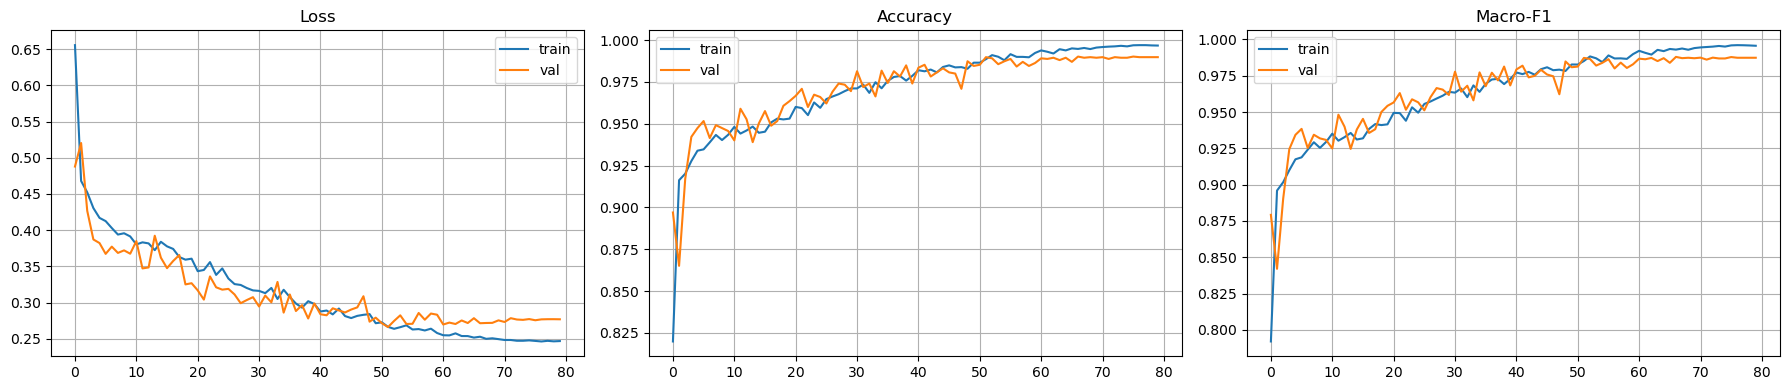

In [10]:
# ---------------- Train ----------------
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=config.label_smoothing)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_epochs)
scaler = GradScaler(enabled=config.use_amp)

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_macro_f1": [], "val_macro_f1": [],
}

best_val_f1 = -1.0
best_epoch = -1
patience_counter = 0
best_ckpt_path = config.output_dir / "best_vit_fy4b.pth"

for epoch in range(config.num_epochs):
    train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
    val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None, scaler=None)
    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_acc"].append(val_metrics["acc"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])

    improved = val_metrics["macro_f1"] > best_val_f1
    if improved:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_macro_f1": best_val_f1,
            "config": config.__dict__,
        }, best_ckpt_path)
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1:03d}/{config.num_epochs}] | "
        f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
        f"train_acc={train_metrics['acc']:.4f} val_acc={val_metrics['acc']:.4f} | "
        f"train_f1={train_metrics['macro_f1']:.4f} val_f1={val_metrics['macro_f1']:.4f}"
    )

    if patience_counter >= config.early_stopping_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print(f"Best epoch: {best_epoch} | Best val macro-F1: {best_val_f1:.4f}")

with open(config.output_dir / "history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

plot_history(history)

C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):
C:\Users\38851\AppData\Local\Temp\ipykernel_47852\662852623.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


Best checkpoint epoch: 67
Val   -> loss: 0.0760, acc: 0.9902, macro_f1: 0.9880, weighted_f1: 0.9902
Test  -> loss: 0.1628, acc: 0.9584, macro_f1: 0.9310, weighted_f1: 0.9595

Validation classification report:
              precision    recall  f1-score   support

       Clear     0.9844    0.9651    0.9746       458
       Water     0.9764    0.9738    0.9751       382
 SuperCooled     0.9868    1.0000    0.9934       750
       Mixed     0.9964    1.0000    0.9982       561
         Ice     1.0000    0.9972    0.9986       703

    accuracy                         0.9902      2854
   macro avg     0.9888    0.9872    0.9880      2854
weighted avg     0.9902    0.9902    0.9902      2854


Test classification report:
              precision    recall  f1-score   support

       Clear     0.9909    0.9440    0.9669      3590
       Water     0.8056    0.9457    0.8700       644
 SuperCooled     0.8693    0.9939    0.9275       328
       Mixed     0.8280    0.9747    0.8953        79
  

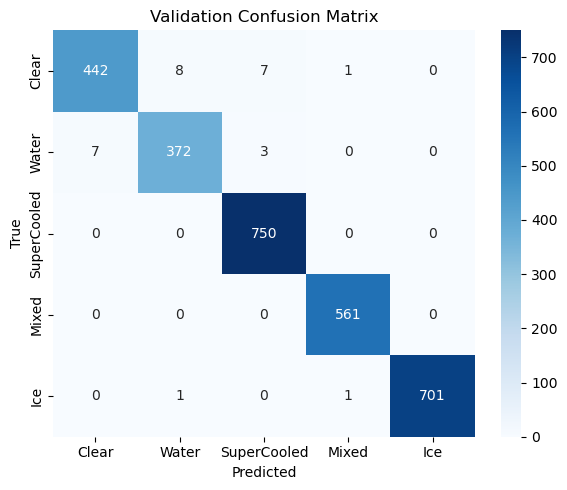

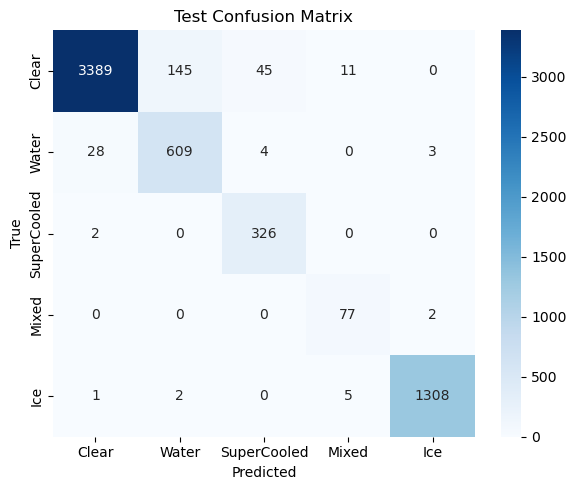

In [11]:
# ---------------- Final evaluation on val/test ----------------
checkpoint = torch.load(best_ckpt_path, map_location=config.device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

criterion_eval = nn.CrossEntropyLoss(weight=class_weights)
val_metrics = run_one_epoch(model, val_loader, criterion_eval)
test_metrics = run_one_epoch(model, test_loader, criterion_eval)

print("Best checkpoint epoch:", checkpoint["epoch"])
print("Val   -> loss: {:.4f}, acc: {:.4f}, macro_f1: {:.4f}, weighted_f1: {:.4f}".format(
    val_metrics["loss"], val_metrics["acc"], val_metrics["macro_f1"], val_metrics["weighted_f1"]
))
print("Test  -> loss: {:.4f}, acc: {:.4f}, macro_f1: {:.4f}, weighted_f1: {:.4f}".format(
    test_metrics["loss"], test_metrics["acc"], test_metrics["macro_f1"], test_metrics["weighted_f1"]
))

print("\nValidation classification report:")
print(classification_report(val_metrics["targets"], val_metrics["preds"], target_names=config.class_names, digits=4))

print("\nTest classification report:")
print(classification_report(test_metrics["targets"], test_metrics["preds"], target_names=config.class_names, digits=4))

plot_confmat(val_metrics["targets"], val_metrics["preds"], config.class_names, title="Validation Confusion Matrix")
plot_confmat(test_metrics["targets"], test_metrics["preds"], config.class_names, title="Test Confusion Matrix")


Batch images shape: torch.Size([128, 15, 64, 64])
Batch labels shape: torch.Size([128])
Unique labels in batch: [0, 1, 2, 3, 4]


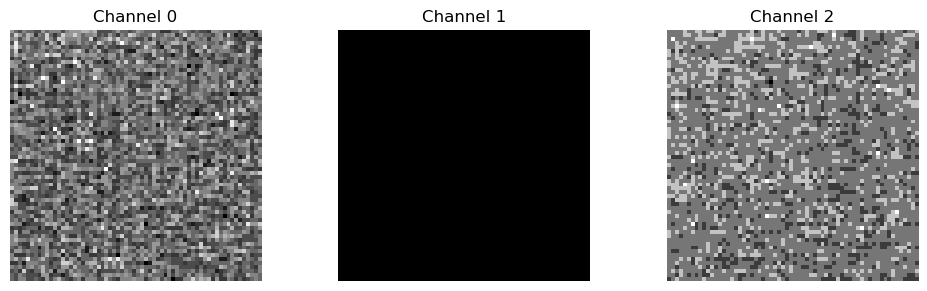

In [12]:
# ---------------- Optional: inspect a batch ----------------
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Unique labels in batch:", sorted(labels.unique().tolist()))

# Display the first 3 channels only for a quick sanity check; this is not true RGB
sample = images[0].numpy()
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    axes[i].imshow(sample[i], cmap='gray')
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()